# Análisis de Variables Predictivas para $\omega$ (Término Dinámico)

El objetivo de este notebook es explorar y determinar las relaciones e importancia de variables cinemáticas (velocidad, aceleraciones) y las topográficas extraídas del LiDAR (`phi_lidar`, `rugosidad`, etc.) sobre la variable `gz` (tasa de guiñada o *yaw rate*), que es la principal variable en la componente centrífuga/dinámica del índice de estabilidad (SI).

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Estilo de gráficos
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Carga y Preparación de Datos
Cargaremos archivos del conjunto `featured`, que ya contiene combinadas las variables inerciales puras del vehículo y las variables del terreno calculadas del LiDAR.

In [12]:
def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'Doback-Data').exists():
            return candidate
    raise RuntimeError("No se encontró la raíz del repositorio con 'Doback-Data'.")

repo_root = find_repo_root(Path.cwd().resolve())
data_dir = repo_root / 'Doback-Data' / 'featured'

csv_files = sorted(data_dir.glob('DOBACK*.csv'))
print(f"Archivos detectados con patrón DOBACK*.csv: {len(csv_files)}")

dfs = []
failed_files = []
for f in csv_files:
    try:
        dfs.append(pd.read_csv(f, low_memory=False))
    except Exception as e:
        failed_files.append((f.name, str(e)))

if failed_files:
    print(f"Advertencia: {len(failed_files)} archivos no se pudieron leer.")
    for name, err in failed_files[:10]:
        print(f" - {name}: {err}")
    if len(failed_files) > 10:
        print(f" ... y {len(failed_files) - 10} errores adicionales.")

if not dfs:
    raise RuntimeError("No se pudieron cargar datos de ningún archivo DOBACK*.csv en 'featured'.")

df = pd.concat(dfs, ignore_index=True)
print(f"Datos cargados: {df.shape[0]} filas observadas y {df.shape[1]} variables desde {len(dfs)} archivos.")

Archivos detectados con patrón DOBACK*.csv: 1185
Datos cargados: 1609105 filas observadas y 78 variables desde 1185 archivos.


## 2. Predictores y Vector Objetivo

In [13]:
# Target para el término dinámico: 
target = 'gz' # Asumimos 'gz' como proxy/equivalente de ω (velocidad angular en el eje Z)

# Separación de variables de interés
kinematic_cols = ['speed_kmh', 'ax', 'ay', 'az', 'gx', 'gy', 'roll', 'pitch']
lidar_cols = ['phi_lidar', 'tri', 'ruggedness', 'z_std', 'z_range']

# Filtrar los datos asegurando que no haya NaNs en estas columnas esenciales
cols_to_keep = [target] + kinematic_cols + lidar_cols
# Validar cuáles de estas existen en verdad en el df cargado
cols_to_keep = [col for col in cols_to_keep if col in df.columns]

df_clean = df.dropna(subset=cols_to_keep).copy()
print(f"Datos analizables tras limpiar valores nulos o LiDAR faltante: {df_clean.shape[0]} filas.")

Datos analizables tras limpiar valores nulos o LiDAR faltante: 1607639 filas.


### Ingeniería de Características (Feature Engineering)

In [14]:
if 'speed_kmh' in df_clean.columns and 'phi_lidar' in df_clean.columns:
    # Interacción natural: influencia del peralte dependiendo de la velocidad a la que se toma
    df_clean['speed_x_phi'] = df_clean['speed_kmh'] * df_clean['phi_lidar']
    
    # El cuadrado de la velocidad es un componente puro de las fuerzas centrífugas proporcionales a V^2/R
    df_clean['speed_sq'] = df_clean['speed_kmh'] ** 2

    derived_cols = ['speed_x_phi', 'speed_sq']
else:
    derived_cols = []

# Lista final de predictores (quitamos target de la lista)
all_features = [c for c in cols_to_keep if c != target] + derived_cols

## 3. Análisis de Correlación
Matriz para observar correlaciones lineales y de rango.

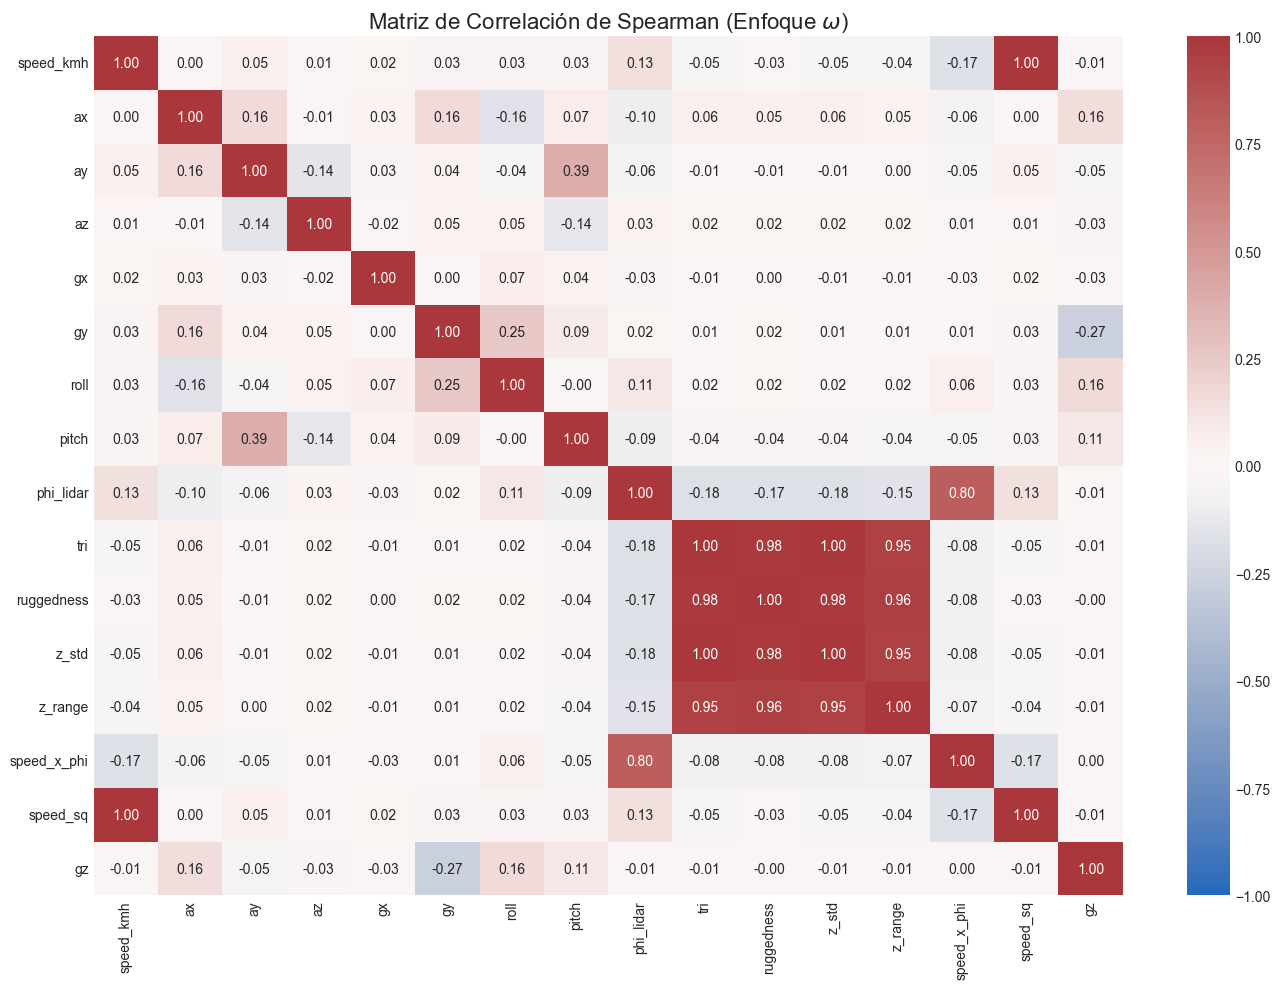

In [15]:
# usamos el método de Spearman (no asume linealidad pura, bueno para geometrías)
corr_matrix = df_clean[all_features + [target]].corr(method='spearman')

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='vlag', fmt='.2f', vmin=-1, vmax=1)
plt.title(f"Matriz de Correlación de Spearman (Enfoque $\\omega$)", fontsize=16)
plt.tight_layout()
plt.show()

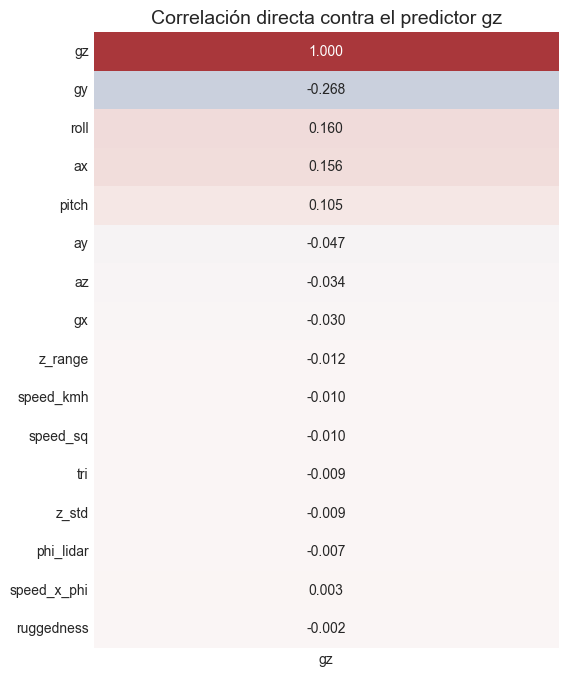

In [16]:
# Visualizar solo cómo el resto de features afectan al target
target_corr = corr_matrix[[target]].sort_values(by=target, key=abs, ascending=False)

plt.figure(figsize=(6, 8))
sns.heatmap(target_corr, annot=True, cmap='vlag', fmt='.3f', vmin=-1, vmax=1, cbar=False)
plt.title(f"Correlación directa contra el predictor {target}", fontsize=14)
plt.show()

## 4. Importancia Predictiva (Feature Importance con Machine Learning)
Para efectos de predicción futura, los modelos no lineales (como RandomForest) son ideales para capturar las dinámicas físicas no proporcionales y evaluar la cantidad neta de información que aporta cada señal, ya sea cinemática pura o provista por el LiDAR.

C:\Users\alexc\AppData\Local\Temp\ipykernel_54856\1141760257.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='magma')


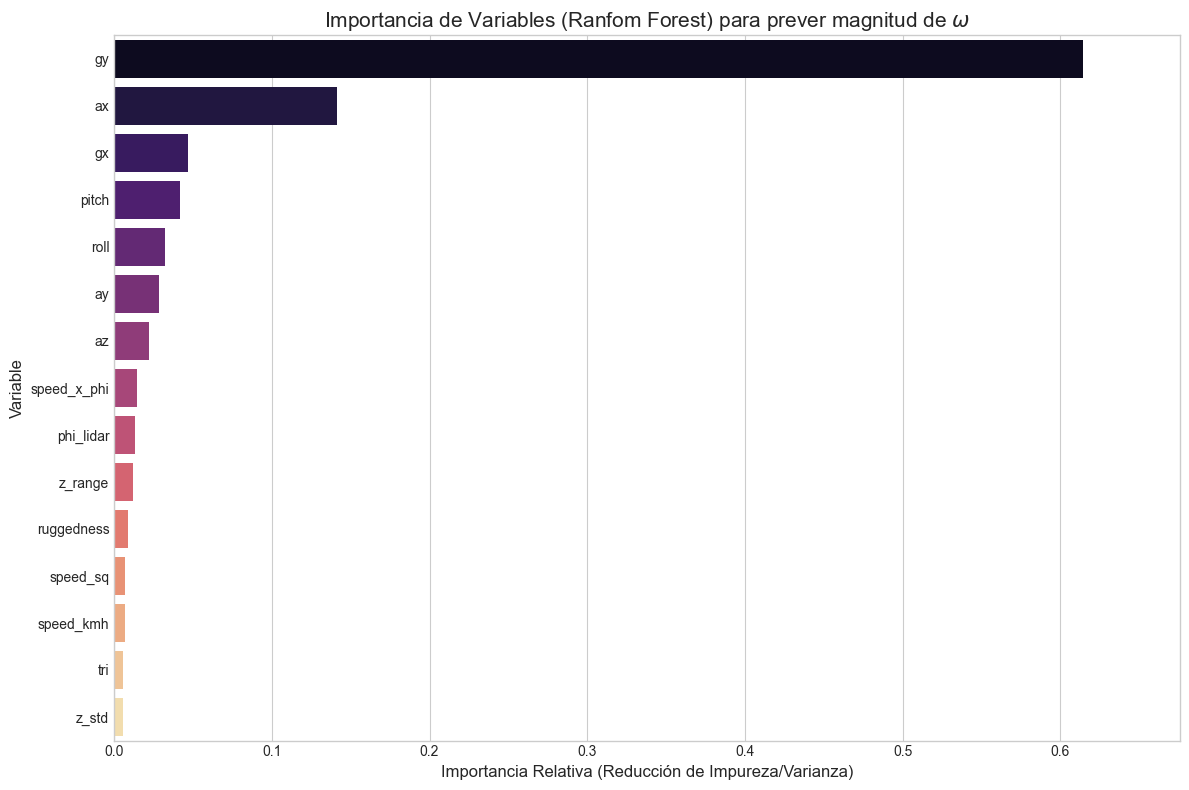

In [17]:
# Seleccionamos el diseño X predictivo, y la variable target Y
X = df_clean[all_features]

# Para entender el impacto sobre la *intensidad* del giro/balance dinámico (las curvas a ambos lados pesan igual), 
# puede ser útil usar el valor absoluto del yaw rate, aunque lo ejecutaremos sobre el raw normal primero:
y = df_clean[target].abs() 

# Muestreo si el conjunto de datos es exageradamente grande (evita saturación de memoria durante el análisis)
if len(X) > 40000:
    X_sample, _, y_sample, _ = train_test_split(X, y, train_size=40000, random_state=42)
else:
    X_sample, y_sample = X, y

# Entrenar modelo evaluador Random Forest
rf_model = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf_model.fit(X_sample, y_sample)

# Extracción y visualización
importances = rf_model.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='magma')
plt.title("Importancia de Variables (Ranfom Forest) para prever magnitud de $\\omega$", fontsize=15)
plt.xlabel("Importancia Relativa (Reducción de Impureza/Varianza)", fontsize=12)
plt.ylabel("Variable", fontsize=12)
plt.xlim(0, max(importances) * 1.1)
plt.tight_layout()
plt.show()